<!--TABLE OF CONTENTS-->
Contents:
- [Data Preprocessing](#Data-Preprocessing)
  - [Data scaling](#Data-scaling)
  - [Categorical variables](#Categorical-variables)
    - [One-hot encoding](#One-hot-encoding)
    - [Ordinal encoding](#Ordinal-encoding)
    - [Target Encoding](#Target-Encoding)
- [Multiple column transformations](#Multiple-column-transformations)
- [Cross validation and Hyperparameter tuning](#Cross-validation-and-Hyperparameter-tuning)
  - [Grid search](#Grid-search)
  - [Randomized search](#Randomized-search)
  - [Successive Halving search](#Successive-Halving-search)
  - [Other libraries for hyperparameter tuning](#Other-libraries-for-hyperparameter-tuning)
  - [Practice question](#Practice-question)
- [Algorithm chains and pipelines](#Algorithm-chains-and-pipelines)
  - [Building Pipelines](#Building-Pipelines)
  - [The General Pipeline Interface](#The-General-Pipeline-Interface)
  - [Pipeline and ColumnTransformer](#Pipeline-and-ColumnTransformer)
  - [Grid-Searching Which Model To Use](#Grid-Searching-Which-Model-To-Use)
- [Data balancing](#Data-balancing)
  - [Under-sampling](#Under-sampling)
  - [Over-sampling](#Over-sampling)
  - [SMOTE](#SMOTE)
    - [Numerical variables](#Numerical-variables)
    - [Categorical variables](#Categorical-variables)
    - [Mixed data types](#Mixed-data-types)
  - [Avoiding data leakage with pipeline](#Avoiding-data-leakage-with-pipeline)
  - [Key points](#Key-points)

# Data Preprocessing

The following exercise is adapted from Chapter 4 of the book *Introduction to Machine Learning with Python*, by Andreas C. Müller, Sarah Guido.

Regardless of the types of features our data consists of, how we represent them can have an enormous effect on the performance of machine learning models. The question of how to represent our data best for a particular application is part of data preprocessing, and it is one of the main tasks of data scientists trying to solve real-world problems. Representing the data in the right way can have a bigger influence on the performance of a supervised model than the exact parameters we choose.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.inspection import DecisionBoundaryDisplay

## Data scaling
Some algorithms are very sensitive to the scaling of the data.
Therefore, a common practice is to adjust the features so that the data representation is more suitable for these algorithms.
Let's visualize two different scaling techniques: normalization and standardization.
First, let's generate a small synthetic dataset with sklearn's *make_blobs()*.

Text(0.5, 1.0, 'our dataset')

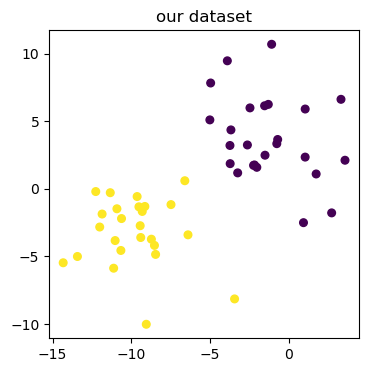

In [2]:
from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples=50, centers=2, random_state=1, cluster_std=3)
plt.figure(figsize=(4,4))
plt.scatter(X[:, 0], X[:, 1], s=30, c=y)
plt.title("our dataset")

The first feature (the x-axis value) is between -15 and 3. The second feature (the y-axis value) is between -10 and 10.
Now, let's scale the data with two different scalers *MinMax* (performs normalization) and *StandardScaler* (performs standardization).

In [3]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

minmax_scaler = MinMaxScaler()
standard_scaler = StandardScaler()
X_minmax = minmax_scaler.fit_transform(X)
X_standard = standard_scaler.fit_transform(X)

Now, let's see the difference:

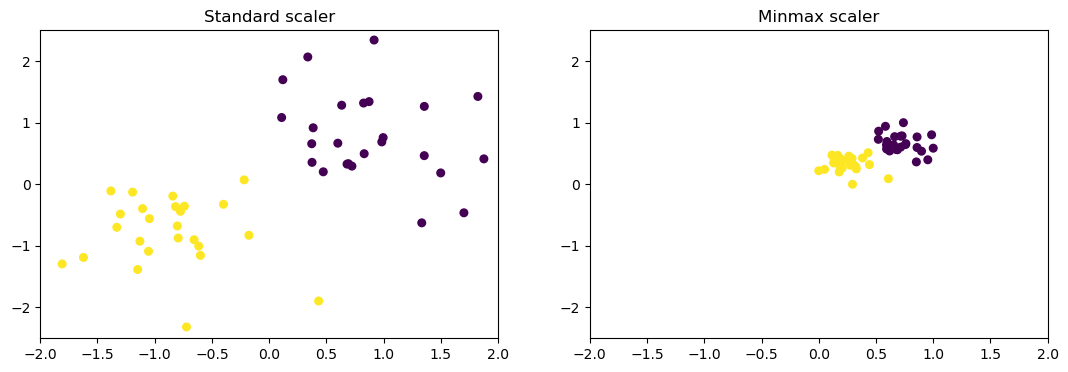

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(13,4))
ax[0].set_title("Standard scaler")
ax[0].scatter(X_standard[:, 0], X_standard[:, 1], s=30, c=y)
ax[0].axis([-2, 2, -2.5, 2.5])

ax[1].set_title("Minmax scaler")
ax[1].scatter(X_minmax[:, 0], X_minmax[:, 1], s=30, c=y )
ax[1].axis([-2, 2, -2.5, 2.5]);


The *StandardScaler* in *sklearn* ensures that for each feature the mean is 0 and the variance is 1, bringing all features to the same magnitude. However, this scaling does not ensure any particular minimum and maximum values for the features.

The *MinMaxScaler*, on the other hand, shifts the data such that all features are exactly between 0 and 1. For the two-dimensional dataset this means all of the data is contained within the rectangle created by the x-axis between 0 and 1 and the y-axis between 0 and 1.

Previously, we have mentioned that it is important that we should fit the scaler only on the training data and transform the test data. This way we avoid any data leakage.
Now, let's also demonstrate why should we apply the same transformation to the training set and the test set for the supervised model.

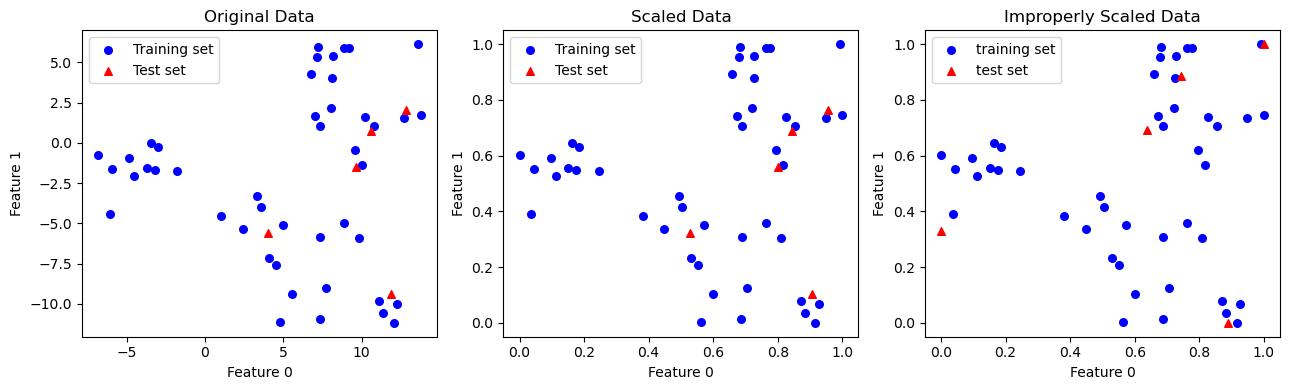

In [5]:
from sklearn.model_selection import train_test_split

X, y = make_blobs(n_samples=50, centers=5, random_state=4, cluster_std=2)
X_train, X_test = train_test_split(X, random_state=5, test_size=.1)

fig, ax = plt.subplots(1, 3, figsize=(13, 4))
ax[0].scatter(X_train[:, 0], X_train[:, 1], label="Training set", s=30, c = 'blue')
ax[0].scatter(X_test[:, 0], X_test[:, 1], marker='^', label="Test set", s=30,c = 'red')
ax[0].legend(loc='upper left')
ax[0].set_title("Original Data")

# scale the data using MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# visualize the properly scaled data
ax[1].scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], label="Training set", s=30, c = 'blue')
ax[1].scatter(X_test_scaled[:, 0], X_test_scaled[:, 1], marker='^', label="Test set", s=30,c = 'red')
ax[1].legend(loc='upper left')
ax[1].set_title("Scaled Data")

# rescale the test set separately
# so test set min is 0 and test set max is 1
# DO NOT DO THIS! For illustration purposes only.
test_scaler = MinMaxScaler()
test_scaler.fit(X_test)
X_test_scaled_badly = test_scaler.transform(X_test)

# visualize wrongly scaled data
ax[2].scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], label="training set", s=30, c = 'blue')
ax[2].scatter(X_test_scaled_badly[:, 0], X_test_scaled_badly[:, 1], marker='^',  label="test set", s=30,c = 'red')
ax[2].legend(loc='upper left')
ax[2].set_title("Improperly Scaled Data")

for axi in ax:
    axi.set_xlabel("Feature 0")
    axi.set_ylabel("Feature 1")
fig.tight_layout()

The first subplot is an unscaled two-dimensional dataset, with the training set shown as blue circles and the test set shown as red triangles. The second subplot is the same data, but scaled using the *MinMaxScaler*. Here, we called `fit` on the training set, and then called `transform` on the training and test sets. We can see that the dataset in the second subplot looks identical to the first; only the ticks on the axes have changed. Now all the features are between 0 and 1. We can also see that the minimum and maximum feature values for the test data (the triangles) are not 0 and 1.

The third subplot shows what would happen if we scaled the training set and test set separately. In this case, the minimum and maximum feature values for both the training and the test set are 0 and 1. But now the dataset looks different. The test points moved, as they were scaled differently. We changed the arrangement of the data in an arbitrary way. Clearly this is not what we want to do. Hence, **we should use `fit` on the training set only, and then `transform` on the training and test sets**.

## Categorical variables

For this part of the exercise, we will use the dataset of adult incomes in the United States, derived from the 1994 census database. The task of the dataset is to predict whether a worker has an income of over 50,000 or under 50,000.
Place the downloaded csv file *census_data* in the same directory as your notebook and import it.



In [6]:
data = pd.read_csv('census_data.csv')
# For illustration purposes, we will only select some of the columns
data = data[['age', 'workclass', 'education',  'capital-gain-category', 'hours-per-week', 'occupation', 'income']]
data.head()

,age,workclass,education,capital-gain-category,hours-per-week,occupation,income
0,39,State-gov,Bachelors,cat2,40,Adm-clerical,<=50K
1,50,Self-emp-not-inc,Bachelors,cat1,13,Exec-managerial,<=50K
2,38,Private,HS-grad,cat1,40,Handlers-cleaners,<=50K
3,53,Private,11th,cat1,40,Handlers-cleaners,<=50K
4,28,Private,Bachelors,cat1,40,Prof-specialty,<=50K


In [7]:
data.shape

(32561, 7)

In [8]:
data.dtypes

age                       int64
workclass                object
education                object
capital-gain-category    object
hours-per-week            int64
occupation               object
income                   object
dtype: object

The *workclass*, *education*, *	capital-gain-category*, and *occupation* features are categorical features. All of them come from a fixed list of possible values, as opposed to a range, and denote a qualitative property, as opposed to a quantity. In our example, target variable is income, and it is also categorical.

### One-hot encoding

By far the most common way to represent categorical variables is using the one-hot-encoding or one-out-of-N encoding, also known as dummy variables. The idea behind dummy variables is to replace a categorical variable with one or more new features that can have the values 0 and 1. We can represent any number of categories by introducing one new feature per category, as described here. In general, this encoding works well if there are only a few levels.
For illustration purposes, we will do one hot encoding for all categorical features, even though education is ordinal, as the values it can take can be ordered.

Let's see the values that the *workclass* feature can take.

In [9]:
data.workclass.value_counts()

workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
?                    1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64

*Sklearn* has also a function for one-hot encoding. *OneHotEncoder* assumes all features are categorical.

In [10]:
from sklearn.preprocessing import OneHotEncoder

Let us select only categorical features using `select_dtypes` method which returns a subset of the DataFrame’s columns based on the column dtypes. We can define with *include* or *exclude* a list of data types to be included or excluded.

In [11]:
X=data.drop(columns='income')
y=data['income']
categorical=X.select_dtypes(exclude='number').columns
categorical

Index(['workclass', 'education', 'capital-gain-category', 'occupation'], dtype='object')

In [12]:
numerical= X.select_dtypes(include='number').columns
numerical

Index(['age', 'hours-per-week'], dtype='object')

We can now quickly visualize the different values that each categorical variable can take:

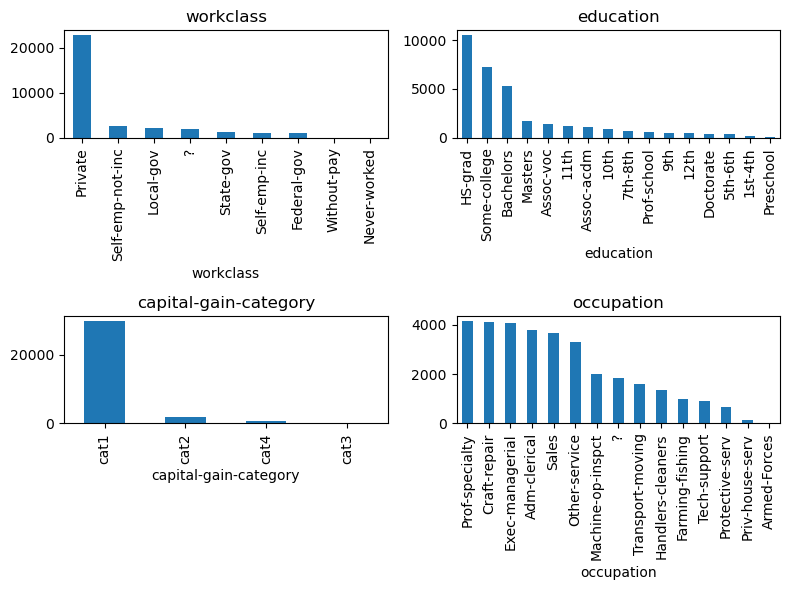

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(8, 6))
axes = axes.flatten()

for i, categorical_variable in enumerate(categorical):
    X[categorical_variable].value_counts().plot(kind='bar', ax=axes[i], title=categorical_variable)

plt.tight_layout()
plt.show()

*OneHotEncoder* has a parameter *drop* with which we can specify whether we want to drop one of the dummy variables in order to avoid collinearity.  We could do this with *OneHotEncoder(drop ='first')*.  Note that this is useful in situations where perfectly collinear features cause problems, such as when feeding the resulting data into an unregularized linear regression model. (When features are highly correlated, small changes in the data can cause large fluctuations in the regression coefficients, and also it becomes harder to determine the importance of each feature). However, dropping one category breaks the symmetry of the original representation and can therefore induce a bias in downstream models, for instance for penalized linear classification or regression model or decision trees.
Let's fit *OneHotEncoder* to categorical variables only.
We will also change the default value of the parameter *sparse_output* which defines whether the encoder will return a sparse matrix or an array. Since we will later convert the output of the encoder to pandas dataframe, we want the output to be an array.

In [14]:
ohe = OneHotEncoder(drop='first', sparse_output=False)
ohe.fit(X[categorical])
ohe.categories_

[array(['?', 'Federal-gov', 'Local-gov', 'Never-worked', 'Private',
        'Self-emp-inc', 'Self-emp-not-inc', 'State-gov', 'Without-pay'],
       dtype=object),
 array(['10th', '11th', '12th', '1st-4th', '5th-6th', '7th-8th', '9th',
        'Assoc-acdm', 'Assoc-voc', 'Bachelors', 'Doctorate', 'HS-grad',
        'Masters', 'Preschool', 'Prof-school', 'Some-college'],
       dtype=object),
 array(['cat1', 'cat2', 'cat3', 'cat4'], dtype=object),
 array(['?', 'Adm-clerical', 'Armed-Forces', 'Craft-repair',
        'Exec-managerial', 'Farming-fishing', 'Handlers-cleaners',
        'Machine-op-inspct', 'Other-service', 'Priv-house-serv',
        'Prof-specialty', 'Protective-serv', 'Sales', 'Tech-support',
        'Transport-moving'], dtype=object)]

The attribute *categories_* lists the categories of each feature determined during fitting (in order of the features in X and corresponding with the output of transform). This includes the category specified in drop (if any).

Now let's do `transform`:

In [15]:
X_cat= ohe.transform(X[categorical])
encoder_feature_names = ohe.get_feature_names_out(categorical)
encoder_feature_names

array(['workclass_Federal-gov', 'workclass_Local-gov',
       'workclass_Never-worked', 'workclass_Private',
       'workclass_Self-emp-inc', 'workclass_Self-emp-not-inc',
       'workclass_State-gov', 'workclass_Without-pay', 'education_11th',
       'education_12th', 'education_1st-4th', 'education_5th-6th',
       'education_7th-8th', 'education_9th', 'education_Assoc-acdm',
       'education_Assoc-voc', 'education_Bachelors',
       'education_Doctorate', 'education_HS-grad', 'education_Masters',
       'education_Preschool', 'education_Prof-school',
       'education_Some-college', 'capital-gain-category_cat2',
       'capital-gain-category_cat3', 'capital-gain-category_cat4',
       'occupation_Adm-clerical', 'occupation_Armed-Forces',
       'occupation_Craft-repair', 'occupation_Exec-managerial',
       'occupation_Farming-fishing', 'occupation_Handlers-cleaners',
       'occupation_Machine-op-inspct', 'occupation_Other-service',
       'occupation_Priv-house-serv', 'occupation

Let's now convert the array to pandas dataframe:

In [16]:
X_cat= pd.DataFrame(X_cat, columns = encoder_feature_names)

Let's now concatenate the transformed categorical with unchanged numerical variables.

In [17]:
X_num = X[numerical]
X_enc = pd.concat([X_num, X_cat], axis = 1)
print(X_enc.shape)

(32561, 42)


Let us now see how the encoded data frame looks like. As we saw we now have 40 columns.

In [18]:
X_enc.head()

,age,hours-per-week,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,...,occupation_Farming-fishing,occupation_Handlers-cleaners,occupation_Machine-op-inspct,occupation_Other-service,occupation_Priv-house-serv,occupation_Prof-specialty,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving
0,39,40,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,50,13,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,38,40,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,53,40,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,28,40,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


OneHotEncoder supports aggregating infrequent categories into a single output for each feature. The parameters to enable the gathering of infrequent categories are *min_frequency* and *max_categories*.

- *min_frequency* is either an integer greater or equal to 1, or a float in the interval (0, 1). If *min_frequency* is an integer, categories with a cardinality smaller than *min_frequency* will be considered infrequent. If *min_frequency* is a float, categories with a cardinality smaller than this fraction of the total number of samples will be considered infrequent. The default value is 1, which means every category is encoded separately.

- *max_categories* is either None or any integer greater than 1. This parameter sets an upper limit to the number of output features for each input feature. *max_categories* includes the feature that combines infrequent categories.

Now, let's set for our one-hot encoder that if a category appears in less than 1% of all the data, it should be considered infrequent.

In [19]:
ohe_inf = OneHotEncoder(min_frequency=0.01, sparse_output=False)
ohe_inf.fit(X[categorical])
ohe_inf.get_feature_names_out()

array(['workclass_?', 'workclass_Federal-gov', 'workclass_Local-gov',
       'workclass_Private', 'workclass_Self-emp-inc',
       'workclass_Self-emp-not-inc', 'workclass_State-gov',
       'workclass_infrequent_sklearn', 'education_10th', 'education_11th',
       'education_12th', 'education_5th-6th', 'education_7th-8th',
       'education_9th', 'education_Assoc-acdm', 'education_Assoc-voc',
       'education_Bachelors', 'education_Doctorate', 'education_HS-grad',
       'education_Masters', 'education_Prof-school',
       'education_Some-college', 'education_infrequent_sklearn',
       'capital-gain-category_cat1', 'capital-gain-category_cat2',
       'capital-gain-category_cat4',
       'capital-gain-category_infrequent_sklearn', 'occupation_?',
       'occupation_Adm-clerical', 'occupation_Craft-repair',
       'occupation_Exec-managerial', 'occupation_Farming-fishing',
       'occupation_Handlers-cleaners', 'occupation_Machine-op-inspct',
       'occupation_Other-service', 'occup

We see from the previous output that for the feature occupation we have now a category called 'occupation_infrequent_sklearn'. We can check which categories are aggregated in this category:

In [20]:
ohe_inf.infrequent_categories_

[array(['Never-worked', 'Without-pay'], dtype=object),
 array(['1st-4th', 'Preschool'], dtype=object),
 array(['cat3'], dtype=object),
 array(['Armed-Forces', 'Priv-house-serv'], dtype=object)]

We see that two categories 'Armed-Forces' and 'Priv-house-serv' are grouped. Checking the presence of these categories in the data we can confirm that it is less than 1%.

In [21]:
X['occupation'].value_counts(normalize=True)

occupation
Prof-specialty       0.127146
Craft-repair         0.125887
Exec-managerial      0.124873
Adm-clerical         0.115783
Sales                0.112097
Other-service        0.101195
Machine-op-inspct    0.061485
?                    0.056601
Transport-moving     0.049046
Handlers-cleaners    0.042075
Farming-fishing      0.030527
Tech-support         0.028500
Protective-serv      0.019932
Priv-house-serv      0.004576
Armed-Forces         0.000276
Name: proportion, dtype: float64

These levels were grouped together not because they are similar, but because we don't really have enough data to say much about them.

If we fitted the *OneHotEncoder* on the training data, as we should do, if some category is very rare, it might appear only when we transform test data. The behavior for this case is handled with the parameter *handle_unknown*:
- error: This is the default behavior, and an error is raised if an unknown category is present during transform.
- ignore: When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. This means that unknown categories will have the same mapping as the dropped category. For this case, we should not drop any category with the *drop* parameter (as the dropped category is represented with all the zeros of the dummy variables).
- infrequent_if_exist: When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists.

### Ordinal encoding

Categorical ordinal variables have categories that follow a logical ordering. Some examples of ordinal data include:
- Socioeconomic status (low income, middle income or high income)
- Education level (high school, bachelor’s degree, master’s degree or PhD)
- Satisfaction rating (extremely dislike, dislike, neutral, like or extremely like).

Ordinal variables are encoded using scikit-learn *OrdinalEncoder*. In order to use *OrdinalEncoder*, we have to first specify the order in which we would like to encode our ordinal variable. In our case let's encode education level with ordinal encoder (let's assume some ranking between the education levels), and capital-gain-category.

In [22]:
from sklearn.preprocessing import OrdinalEncoder

In [23]:
X['education'].value_counts()

education
HS-grad         10501
Some-college     7291
Bachelors        5355
Masters          1723
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           646
Prof-school       576
9th               514
12th              433
Doctorate         413
5th-6th           333
1st-4th           168
Preschool          51
Name: count, dtype: int64

In [24]:
X['capital-gain-category'].value_counts()

capital-gain-category
cat1    29849
cat2     1942
cat4      613
cat3      157
Name: count, dtype: int64

In [25]:
categories=[['Preschool','1st-4th','5th-6th','7th-8th','9th','10th','11th','12th','HS-grad','Prof-school','Assoc-acdm','Assoc-voc','Some-college','Bachelors','Masters','Doctorate'],
            ['cat1','cat2','cat3','cat4']]
encoder = OrdinalEncoder(categories=categories)
encoder.fit(X[['education','capital-gain-category']] )
encoder.categories_

[array(['Preschool', '1st-4th', '5th-6th', '7th-8th', '9th', '10th',
        '11th', '12th', 'HS-grad', 'Prof-school', 'Assoc-acdm',
        'Assoc-voc', 'Some-college', 'Bachelors', 'Masters', 'Doctorate'],
       dtype=object),
 array(['cat1', 'cat2', 'cat3', 'cat4'], dtype=object)]

In [26]:
X_enc = X.copy()
X_enc[['education','capital-gain-category']] = encoder.transform(X[['education','capital-gain-category']]  )
X_enc.shape

(32561, 6)

In [27]:
X_enc.head()

,age,workclass,education,capital-gain-category,hours-per-week,occupation
0,39,State-gov,13.0,1.0,40,Adm-clerical
1,50,Self-emp-not-inc,13.0,0.0,13,Exec-managerial
2,38,Private,8.0,0.0,40,Handlers-cleaners
3,53,Private,6.0,0.0,40,Handlers-cleaners
4,28,Private,13.0,0.0,40,Prof-specialty


Note that here we remained with the same number of features as we had initially.

In [28]:
X.shape, X_enc.shape

((32561, 6), (32561, 6))

### Target Encoding

When we have categorical features with high cardinality, using one-hot encoding would inflate the feature space making it more computationally expensive for modeling. A classical example of high cardinality categories are location based such as zip code or region. In this case we can use Target Encoding, where each category is encoded based on the average target values for observations belonging to the category, more specifically the encoding scheme mixes the global target mean with the target mean conditioned on the value of the category.

Let's check again how many categories does each categorical feature have using `nunique()` pandas method:

In [29]:
for categorical_variable in categorical:
    print(f'{categorical_variable} has {X[categorical_variable].nunique()} categories')

workclass has 9 categories
education has 16 categories
capital-gain-category has 4 categories
occupation has 15 categories


Let's see how would we encode workclass and occupation with target encoding.

In [30]:
from  sklearn.preprocessing import TargetEncoder

In [31]:
enc = TargetEncoder(target_type='binary')
X_enc = X.copy()
X_enc[['workclass','occupation']] = enc.fit_transform(X[['workclass','occupation']], y)
X_enc.shape

(32561, 6)

We can check what are the values that the categories were mapped to with the following: For feature i, encodings_[i] are the encodings matching the categories listed in categories_[i].

In [32]:
enc.categories_

[array(['?', 'Federal-gov', 'Local-gov', 'Never-worked', 'Private',
        'Self-emp-inc', 'Self-emp-not-inc', 'State-gov', 'Without-pay'],
       dtype=object),
 array(['?', 'Adm-clerical', 'Armed-Forces', 'Craft-repair',
        'Exec-managerial', 'Farming-fishing', 'Handlers-cleaners',
        'Machine-op-inspct', 'Other-service', 'Priv-house-serv',
        'Prof-specialty', 'Protective-serv', 'Sales', 'Tech-support',
        'Transport-moving'], dtype=object)]

In [33]:
enc.encodings_

[array([0.10406847, 0.38626183, 0.29476285, 0.        , 0.21867381,
        0.55696537, 0.28490785, 0.27193089, 0.        ]),
 array([0.10367319, 0.13450071, 0.11845551, 0.22664396, 0.48393209,
        0.11576456, 0.06281553, 0.12490973, 0.04159133, 0.00676869,
        0.44896578, 0.32495995, 0.26930666, 0.30487686, 0.20039788])]

The method *fit_transform* internally relies on a cross fitting scheme to prevent target information from leaking into the train. Below is a diagram this process, but we will describe cross validation in more detail in the next section of this Notebook.

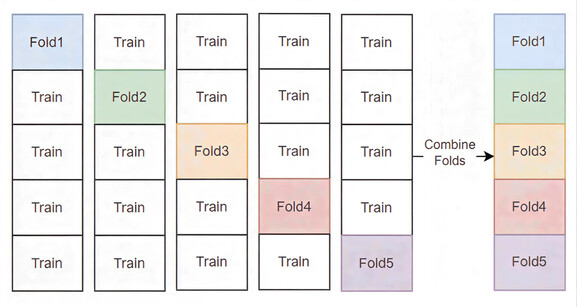

# Multiple column transformations

What if we wanted to scale some numerical features, encode separately nominal and separately ordinal categorical features? So far, we have done column transformation steps separately.
It would be more convenient to have a single transformer able to handle all columns, applying the appropriate transformations to each column. `sklearn` has `ColumnTransformer` for this purpose. Let's use it to apply all the transformations:

In [34]:
from sklearn.compose import ColumnTransformer

ct = ColumnTransformer([
    ('scaling', MinMaxScaler(), ['age', 'hours-per-week']),
    ('one_hot', OneHotEncoder(sparse_output=False, drop='first',
                              min_frequency=0.01, handle_unknown='infrequent_if_exist' ), ['workclass']),
    ('target_enc', TargetEncoder(target_type='binary'), ['occupation']),
    ('ordinal', OrdinalEncoder(categories=categories), ['education','capital-gain-category'] )
], remainder='passthrough')


The constructor of `ColumnTransfmer` requires a list of tuples, where each tuple contains a name of the transformation, user defined, a transformer and a list of names (or indices) of columns
that the transformer should be applied to. In this example, we specify that the numerical
columns should be transformed using the `MinMaxScaler`, that nominal feature workclass is encoded with `OneHotEncoder`, feature occupation will be encoded with `TargetEncoder` and the ordinal features with `OrdinalEncoder`. (We would also need to scale the ordinal encoded feature, but for now, we will ignore this step.)

Here we listed all the columns in the dataframe, as we wished to transform all of them. But we could have had a feature which we did not need to process additionally. By default, only the specified columns in transformers are transformed and combined in the output, and the non-specified columns are dropped. We can change the default behaviour, by specifying the parameter *remainder='passthrough'*, and with this, all remaining columns that were not specified in transformers, but present in the data passed to fit will be automatically passed through.

The default configuration for displaying a `ColumnTransformer` is 'text' where set_config(display='text'). To visualize the diagram in the notebook, use can use `set_config(display='diagram')` and then output the `ColumnTransformer` object.

In [35]:
from sklearn import set_config
set_config(display="diagram")
ct

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scaling', ...), ('one_hot', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``fe

Now, let's split our data into train and test. Then, let's fit our *ColumnTransformer* to our train data and then transform it.

In [36]:
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

ct.fit(X_train, y_train)
X_train_trans = ct.transform(X_train)
X_train_trans.shape

(24420, 12)

We can see that we obtained 12 features: 2 numerical, 2 ordinal and (9-2) dummy features for workclass, here we did not drop one dummy variable, as we will be using a regularized model later, but we grouped 2 infrequent categories together, and 1 target encoded feature, occupation. Let's see the list of the features for our transformed dataset, using *get_feature_names_out()* method on the fitted ColumnTransformer.

In [37]:
ct.get_feature_names_out()

array(['scaling__age', 'scaling__hours-per-week',
       'one_hot__workclass_Federal-gov', 'one_hot__workclass_Local-gov',
       'one_hot__workclass_Private', 'one_hot__workclass_Self-emp-inc',
       'one_hot__workclass_Self-emp-not-inc',
       'one_hot__workclass_State-gov',
       'one_hot__workclass_infrequent_sklearn', 'target_enc__occupation',
       'ordinal__education', 'ordinal__capital-gain-category'],
      dtype=object)

Let's access the one hot encoder inside the column transformer using the attribute `named_transformers_` to check that we did indeed end up with two categories grouped in *'one_hot__workclass_infrequent_sklearn'* category:

In [38]:
ct.named_transformers_['one_hot'].infrequent_categories_

[array(['Never-worked', 'Without-pay'], dtype=object)]

Note that we fitted the column transformer with X and y. Here we needed y only because we used target encoding. If we did not use it, we would fit with only X.

Now, we can build a *LogisticRegression* model. Since we transformed our train data, the same transformations must be done for the test data. As before, we only apply the *transform* on the test data.

In [39]:
from sklearn.metrics import classification_report
logreg = LogisticRegression(solver="liblinear", random_state=42)
logreg.fit(X_train_trans, y_train)

X_test_trans = ct.transform(X_test)
y_pred=logreg.predict(X_test_trans)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       <=50K       0.82      0.94      0.88      6159
        >50K       0.66      0.38      0.48      1982

    accuracy                           0.80      8141
   macro avg       0.74      0.66      0.68      8141
weighted avg       0.78      0.80      0.78      8141



# Cross validation and Hyperparameter tuning

To evaluate our supervised models, so far we have split our dataset into a training set and a test set using the `train_test_split` function, built a model on the training set by calling the `fit` method, and evaluated it on the test set using a variety of metrics.
Note, the reason we split our data into training and test sets is that we are interested in measuring how well our model *generalizes* to new, previously unseen data. We are not interested in how well our model fit the training set, but rather in how
well it can make predictions for data that was not observed during training.

Cross-validation is a statistical method of evaluating generalization performance that is more stable and thorough than using a split into a training and a test set. In cross-validation, the data is instead split repeatedly and multiple models are trained. The
most commonly used version of cross-validation is k-fold cross-validation, where k is a user-specified number, usually 5 or 10. When performing five-fold cross-validation, the data is first partitioned into five parts of (approximately) equal size, called folds.
Next, a sequence of models is trained. The first model is trained using the first fold as the test set, and the remaining folds (2–5) are used as the training set. The model is built using the data in folds 2–5, and then the perfromance metric is evaluated on fold 1. Then another model is built, this time using fold 2 as the test set and the data in folds 1, 3, 4, and 5 as the training set. This process is repeated using folds 3, 4, and 5 as test sets. For each of these five splits of the data into training and test sets, we compute the perfromance metric. In the end, we have collected five performance values.  Usually, the first fifth of the data is the first fold, the second fifth of the data is the second fold, and so on. (Note: this is not valid for time series.)

Let's now import the iris dataset, using the parameter *return_X_y=True* to return the features and label directly. We will also shuffle the data, since the data is sorted by labels, and we want to have data instances of different labels in each fold. Later in this notebook, we will return to this and discuss better approach to achieve this, but for now, we will just shuffle the data.

In [40]:
from sklearn.datasets import load_iris
from sklearn.utils import shuffle
X, y = load_iris(return_X_y=True)
X, y = shuffle(X, y, random_state=0)

Let's check the distribution of the target variable.

In [41]:
pd.Series(y).value_counts()

2    50
1    50
0    50
Name: count, dtype: int64

## Grid search

The most commonly used method is grid search, which basically means trying all possible combinations of the
parameters of interest.

In [42]:
X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, random_state=0, test_size=0.2)
# split train+validation set into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, random_state=1, test_size=0.3)

In [43]:
print(f'Size of training set: {X_train.shape[0]}, size of validation set: {X_val.shape[0]} size of test set {X_test.shape[0]}')

Size of training set: 84, size of validation set: 36 size of test set 30


The distinction between the training set, validation set, and test set is fundamentally important to applying machine learning methods in practice. Any choices made based on the test set accuracy "leak" information from the test set into the model.
Therefore, it is important to keep a separate test set, which is only used for the final evaluation. It is good practice to do all exploratory analysis and model selection using the combination of a training and a validation set, and reserve the test set for a final evaluation. Instead of
using a single split into a training and a validation set, we can use cross-validation to
evaluate the performance of each parameter combination.

Because grid search with cross-validation is such a commonly used method to adjust parameters, `sklearn` provides the `GridSearchCV` class, which implements it in the form of an estimator. To use the `GridSearchCV` class, we first need to specify the parameters we want to search over using a dictionary. `GridSearchCV` will then perform all the necessary model fits. The keys of the dictionary are the names of parameters we want to adjust (as given when constructing the model, in this case, *C* and *penalty*), and the values are the parameter settings we want to try out. The default metric for evaluation used will be the default score of the estimator, but a different `scoring` metric can be set. We should choose the appropriate evaluation metric based on which we will select the best hyperparameters. Here is the link to check the possible options: https://scikit-learn.org/stable/modules/model_evaluation.html#scoring-string-names

In [44]:
from sklearn.model_selection import GridSearchCV

In [45]:
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10],
               'l1_ratio': [1,0]}

In [46]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0, test_size=0.2)

In [47]:
print(f'Size of training set: {X_train.shape[0]}, size of test set {X_test.shape[0]}')

Size of training set: 120, size of test set 30


In [48]:
grid_search = GridSearchCV(LogisticRegression(solver="saga", random_state=42, max_iter=10000), param_grid, cv=5, n_jobs=-1, scoring='accuracy')

We used accuracy as the metric to choose the parameters with the best performance on the hold out fold, for illustration purpose, but we could have used 'f1', 'roc_auc', 'precision', 'recall' or any other that is the most approapriate based on our business goal.

The grid_search object that we created behaves just like a classifier; we can call the standard methods `fit`, `predict`, and `score` on it. However, when we call `fit`, it will run cross-validation for each combination of parameters we specified in the parameter grid. We have 5 different values for *C*, and 2 for *penalty*, giving in total 10 combinations. For each combination 5-fold CV is used, meaning in total 50 models are trained. And here we only have two parameters we want to tune. Hence, when running a grid search over many parameters and on large datasets it can be computationally challenging. One way to speed things up is with parallelization.

Note that in cross-validation, for each fold, the process can be done in parallel, so for 5-fold CV, if we have computational resources, we could run 5 processes in parallel. With the parameter `n_jobs`, we could specify the number of jobs (number of concurrent threads or processes) to run in parallel. If this parameter is not specified, it means only 1 job is run at a time, while `n_jobs=-1` means that all available CPUs should be used. However, if the training takes a lot of time, allocating all CPUs to cross-validation will leave us without any resources to do other things on the computer.

To check how many *logical* CPUs we have, we can use `os.cpu_count()`:

In [49]:
import os
os.cpu_count()

8

In [50]:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...solver='saga')
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.001, 0.01, ...], 'l1_ratio': [1, 0]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fo

Now that this is fit, we can ask for the best parameters as follows:

In [51]:
grid_search.best_params_

{'C': 10, 'l1_ratio': 1}

The best cross-validation score (the mean accuracy as we used that scoring metric over the different splits for this parameter setting) is stored in `best_score_`:

In [52]:
grid_search.best_score_

np.float64(0.9833333333333332)

The results of a grid search can be found
in the `cv_results_` attribute, which is a dictionary storing all aspects of the search. We can convert it to a pandas dataframe to view it:

In [53]:
results = pd.DataFrame(grid_search.cv_results_)
results.head(3)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_l1_ratio,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.006466,0.001033,0.003935,0.001897,0.001,1,"{'C': 0.001, 'l1_ratio': 1}",0.333333,0.333333,0.333333,0.333333,0.333333,0.333333,0.000000,9
1,0.010905,0.002163,0.004970,0.002044,0.001,0,"{'C': 0.001, 'l1_ratio': 0}",0.708333,0.708333,0.750000,0.791667,0.958333,0.783333,0.092796,8
2,0.005359,0.000803,0.002940,0.001124,0.010,1,"{'C': 0.01, 'l1_ratio': 1}",0.333333,0.333333,0.333333,0.333333,0.333333,0.333333,0.000000,9


By default an estimator is retrained using the best found parameters on the whole train dataset. We can access the model with `.best_estimator_` attribute and test its perfromance on the test set:

In [54]:
grid_search.best_estimator_.score(X_test, y_test)

0.9666666666666667

Or we could have just used the score method directly on the grid_search:

In [55]:
grid_search.score(X_test, y_test)

0.9666666666666667

The important thing here is that **we did not use the test set to choose the parameters**, meaning the final test set was only used for the final model evaluation.

## Randomized search

If we had many different paramenters and many values to evaluate, randomized search would be a better option than grid. In contrast to `GridSearchCV`, not all parameter values are tried out, but rather a fixed number of parameter settings is sampled from the specified distributions. The number of parameter settings that are tried is given by *n_iter*.

In [56]:
from sklearn.model_selection import RandomizedSearchCV

In [57]:
from scipy.stats import loguniform

distributions= { 'C': loguniform(0.0001, 10),
                 'l1_ratio': [1,0]}

Using a loguniform distribution instead of a regular uniform distribution will ensure that in a sufficiently large number of trials, the same number of samples will be drawn from the [0.0001, 0.001] range as, for example, the [1, 10] range.

In [58]:
random_search = RandomizedSearchCV(LogisticRegression(solver="saga", random_state=42, max_iter=10000),  distributions, scoring='accuracy', cv=5,  n_iter=10, random_state=1, n_jobs=-1)
random_search.fit(X_train, y_train)
random_search.best_params_

{'C': np.float64(4.600306804490298), 'l1_ratio': 0}

Running the results with a different seed especially for a small number of iterations might lead to different parameters selected.

Now we evaluate the performance of the model with the best parameters on the test set:

In [59]:
random_search.score(X_test, y_test)

0.9666666666666667

Just like in `GridSearchCV` we could change the `scoring` method, use parallelization with `n_jobs`, view `cv_results_` and access the model through `best_estimator`.

If we had a large number of parameters,  would me much more practical choice than `GridSearchCV`. However, there are more efficient approached than `RandomizedSearchCV`.

## Successive Halving search

*Sklearn* also provides the *HalvingGridSearchCV* and *HalvingRandomSearchCV* estimators that can be used to search a parameter space using successive halving . Successive halving (SH) is like a tournament among candidate hyperparameter combinations. It is an iterative selection process where all candidates (the hyperparameter combinations) are evaluated with a small amount of resources at the first iteration. Only some of these candidates are selected for the next iteration, which will be allocated more resources. For parameter tuning, the resource is typically the number of training samples, but it can also be an arbitrary numeric parameter.

We can summarize the procedure via the following steps:

1. Draw a large set of candidate configurations (hyperparameter combinations) via random sampling.
2. Train the models (i.e., each set of hyperparameter combinations) with limited resources, for example, a small subset of the training data (as opposed to using the entire training set).
3. Discard the bottom 50 percent (typical value) based on predictive performance.
4. Go back to step 2 with an increased amount of available resources for each of the surviving configurations.

The steps are repeated until only one hyperparameter configuration remains.

In [60]:
from sklearn.experimental import enable_halving_search_cv

In [61]:
from sklearn.model_selection import HalvingRandomSearchCV
hs = HalvingRandomSearchCV(LogisticRegression(solver="saga", random_state=42, max_iter=10000),
                            param_distributions=distributions,
# specifies the resource that will be allocated to each candidate configuration during evaluation.
# In this case, it's set to 'n_samples', indicating that the number of training samples will be used as the resource.
# Each candidate configuration will be trained and evaluated using a subset of the training data.
                            resource='n_samples',
# select half of candidates in each iteration % (default is 3; select 1/3 of candidates)
                           factor=2,
# The number of candidate parameters to sample, at the first iteration.
                           n_candidates=10,
                           scoring='accuracy',
                           random_state=1,
                           n_jobs=-1)

hs.fit(X_train, y_train)
hs.best_params_

{'C': np.float64(4.600306804490298), 'l1_ratio': 0}

Again, we evaluate the performance of the model with the best parameters on the test set:

In [62]:
hs.score(X_test, y_test)

0.9666666666666667

The `cv_results_` attribute again contains useful information for analyzing the results of a search.

In [63]:
pd.set_option('display.max_columns', None)

In [64]:
results = pd.DataFrame(hs.cv_results_)
results

,iter,n_resources,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_l1_ratio,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,0,30,0.004170,0.001628,0.002676,0.001315,0.012165,1,"{'C': 0.012164941464151846, 'l1_ratio': 1}",0.166667,0.166667,0.333333,0.166667,0.333333,0.233333,0.081650,11,0.500000,0.541667,0.458333,0.458333,0.458333,0.483333,0.033333
1,0,30,0.014340,0.008004,0.002680,0.000654,4.600307,0,"{'C': 4.600306804490298, 'l1_ratio': 0}",0.833333,1.000000,1.000000,1.000000,1.000000,0.966667,0.066667,2,0.958333,0.958333,1.000000,1.000000,1.000000,0.983333,0.020412
2,0,30,0.005708,0.000861,0.002732,0.000686,0.003248,0,"{'C': 0.003248350345086679, 'l1_ratio': 0}",0.166667,0.166667,0.333333,0.166667,0.333333,0.233333,0.081650,11,0.500000,0.541667,0.458333,0.458333,0.458333,0.483333,0.033333
3,0,30,0.006487,0.002322,0.002194,0.000884,0.001515,0,"{'C': 0.0015151125123102904, 'l1_ratio': 0}",0.166667,0.166667,0.333333,0.166667,0.333333,0.233333,0.081650,11,0.500000,0.541667,0.458333,0.458333,0.458333,0.483333,0.033333
4,0,30,0.005795,0.001406,0.001674,0.000487,0.000854,0,"{'C': 0.0008536916958038761, 'l1_ratio': 0}",0.166667,0.166667,0.333333,0.166667,0.333333,0.233333,0.081650,11,0.500000,0.541667,0.458333,0.458333,0.458333,0.483333,0.033333
5,0,30,0.016046,0.004577,0.002503,0.001452,0.223218,0,"{'C': 0.223218499287176, 'l1_ratio': 0}",0.666667,0.666667,0.833333,0.500000,1.000000,0.733333,0.169967,7,0.916667,0.916667,0.791667,0.833333,0.833333,0.858333,0.050000
6,0,30,0.003962,0.001180,0.002550,0.000839,0.049441,1,"{'C': 0.04944059287398676, 'l1_ratio': 1}",0.166667,0.166667,0.333333,0.166667,0.333333,0.233333,0.081650,11,0.500000,0.541667,0.458333,0.458333,0.458333,0.483333,0.033333
7,0,30,0.003592,0.000804,0.002331,0.001491,0.003684,1,"{'C': 0.0036844068804921994, 'l1_ratio': 1}",0.166667,0.166667,0.333333,0.166667,0.333333,0.233333,0.081650,11,0.500000,0.541667,0.458333,0.458333,0.458333,0.483333,0.033333
8,0,30,0.002987,0.000674,0.001736,0.000299,0.001053,1,"{'C': 0.001052594868979971, 'l1_ratio': 1}",0.166667,0.166667,0.333333,0.166667,0.333333,0.233333,0.081650,11,0.500000,0.541667,0.458333,0.458333,0.458333,0.483333,0.033333
9,0,30,0.003552,0.000667,0.001573,0.000369,0.001406,1,"{'C': 0.0014056787147388348, 'l1_ratio': 1}",0.166667,0.166667,0.333333,0.166667,0.333333,0.233333,0.081650,11,0.500000,0.541667,0.458333,0.458333,0.458333,0.483333,0.033333


From the results we can see that in the first round (iter 0), 10 different hyperparameter combinations were used. Since a factor of 2 was specified, this means only 5 combinations were selected for the next round with double the number of resources, i.e., the number of training data points used increased from 30 to 60. Then, half of these 5 combinations were selected, in our case, this is 3, to go to the next round, and the models were trained on all the samples. Out of those 3 combinations, the one with the highest *mean_test_score* (lowest `rank_test_score`) was selected as the best one.

## Other libraries for hyperparameter tuning

Since hyperparameter tuning is a very important step in modeling, many different approaches and libraries were developed to speed up the model tuning when there are many different parameters to be tuned. Here, we will illustrate one such simple library, `scikit-optimize`, which implements Bayesian optimization, which works by considering the previously seen hyperparameter combinations when determining the next set of hyperparameters to evaluate. Bayesian optimization reduces the number of evaluations needed to identify optimal hyperparameters, making it effective for optimizing complex models.
Let's install the `scikit-optimize` library with:

`pip install scikit-optimize`

Note that when importing this library is referred to as: `skopt`.

In [65]:
from skopt import BayesSearchCV
from skopt.space import Real, Categorical

In [66]:
distributions = {
    'l1_ratio': Categorical([0, 1]), # tells the optimizer to pick only 0 or 1
    'C': Real(low=1e-4, high=10,  prior='log-uniform'), # tells the optimizer to pick values between low and high
}

In [67]:
np.int = int
opt = BayesSearchCV(
    LogisticRegression(solver="saga", random_state=42, max_iter=10000),
    distributions,
    scoring='accuracy',
    n_iter=10,
    random_state=1,
    n_jobs=-1
)

opt.fit(X_train, y_train)

,estimator,LogisticRegre...solver='saga')
,search_spaces,"{'C': Real(low=0.00...m='normalize'), 'l1_ratio': Categorical(c...), prior=None)}"
,optimizer_kwargs,None
,n_iter,10
,scoring,'accuracy'
,fit_params,None
,n_jobs,-1
,n_points,1
,iid,'deprecated'
,refit,True
,cv,None


We can see the best parameters:

In [68]:
opt.best_params_

OrderedDict([('C', 2.4458265756334576), ('l1_ratio', 0)])

And, as before, we can access the best model with:

In [69]:
opt.best_estimator_

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",2.4458265756334576
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For

In [70]:
opt.score(X_test, y_test)

0.9666666666666667

## Practice question
Using sklearn's  make_regression, generate a toy dataset:

`X, y = make_regression(n_samples=100, n_features=10, noise=20,  n_informative=5,  random_state=1),`

split it into train and test, then use Ridge regression with grid search cross validation to find the value of $\alpha$ that minimizes the mean square error, and evaluate this model on the test set. Hint: check the `scoring` parameter and the score method  *'neg_root_mean_squared_error'*.

# Algorithm chains and pipelines

The following exercise is adapted from Chapter 6 of *Introduction to Machine Learning with Python* by Andreas C. Müller, Sarah Guido.

In this section we will review how to chain together many different processing steps and machine learning models by using *Pipeline* class.

Let's start with an example of using a scaler, before applying a machine learning model, this time to do regression. We will use house price dataset from `sklearn`, and apply Ridge Regression. Before applying the model, we will split the data into train and test, and fit the `MinMax` scaler on the training data, and then transform both the training and the testing data. Note that we are scaling here to ensure that the gradient descent moves smoothly towards the minima and that the steps for gradient descent are updated at the same rate for all the features.

In [71]:
from sklearn.linear_model import Ridge
from sklearn.metrics import classification_report

# load the data
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()
print(housing.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [72]:
X_train, X_test, y_train, y_test = train_test_split(housing.data, housing.target, random_state=0)
# compute minimum and maximum on the training data
scaler = MinMaxScaler().fit(X_train)
# rescale the training data
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)


ridge = Ridge(alpha=0.01)
ridge.fit(X_train_scaled, y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",0.01
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [73]:
from sklearn.metrics import mean_squared_error, root_mean_squared_error
from sklearn.metrics import r2_score

y_pred=ridge.predict(X_test_scaled)
print('Mean squared error:', mean_squared_error(y_test, y_pred))
print('Root mean squared error:', root_mean_squared_error(y_test, y_pred))
print('R2: ', r2_score(y_test, y_pred))

Mean squared error: 0.5405546467036961
Root mean squared error: 0.735224215259329
R2:  0.5910622391340352


 For `RidgeRegression` the default scoring is the R2. Hence, if we were only interested in R2, we could have simply used the *score* function:

In [74]:
ridge.score(X_test_scaled, y_test)

0.5910622391340352

Now, let's say we want to find better parameters for the ridge using *GridSearchCV*.
   
A naive and WRONG approach to doing a grid search with data scaling might look like this:

In [75]:
from sklearn.model_selection import GridSearchCV
# for illustration purposes only, don't use this code!
param_grid = {'alpha': [0.005, 0.01, 0.05, 0.1, 0.5, 1]  }
grid = GridSearchCV(Ridge(), param_grid=param_grid, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
grid.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Ridge()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.005, 0.01, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate par

Here, we ran the grid search over the parameter of *Ridge* using the scaled data. However, there is a subtle catch in what we just did. When scaling the data, we used ALL the data in the training set to compute the minimum and maximum of the data. We then used the scaled training data to run our grid search using cross-validation. For each split in the cross-validation, some part of the original training set will be declared the training part of the split, and some the test part of the split. The test part is used to measure the performance of a model trained on the training part when applied to new data. However, we already used the information contained in the test part of the split, when scaling the data.

So, the splits in the cross-validation no longer correctly mirror how new data will look to the modeling process. We already leaked information from these parts of the data into our modeling process. This will lead to overly optimistic results during cross-validation, and possibly the selection of sub-optimal parameters.

To get around this problem, the splitting of the dataset during cross-validation should be done BEFORE doing any pre-processing. Any process that extracts knowledge from the dataset should only ever be learned from the training portion of the dataset, and therefore be contained inside the cross-validation loop.

To achieve this in `sklearn` with the `GridSearchCV` function, we can use the `Pipeline` class. The `Pipeline` class is a class that allows "gluing" together multiple processing steps into a single `sklearn` estimator.

The `Pipeline` class itself has `fit`, `predict`, and `score` methods and behaves just like any other model in `sklearn`. The most common use case of the `Pipeline` class is in chaining pre-processing steps (like scaling of the data) together with a supervised model like a classifier.

## Building Pipelines
 First, we build a pipeline object by providing it with a list of steps. Each step is a tuple containing a name (any string of our choosing) and an instance of an estimator:

In [76]:
from sklearn.pipeline import Pipeline
pipe = Pipeline([('scaler', MinMaxScaler()),
                 ('ridge',  Ridge(alpha=0.01))])

Just like for `ColumnTransformer`, when the `sklearn` display setting is set to diagram, with `set_config(display='text')`, we can visualize the pipeline. Note that clicking on the diagram below allows us to see the details of each step:

In [77]:
pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('ridge', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",0.01
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None


Here, we created two steps: the first, called "scaler", is an instance of *MinMaxScaler*, and the second, called "ridge", is an instance of *Ridge*. Now, we can fit the pipeline, like any other `sklearn` estimator:

In [78]:
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('ridge', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",0.01
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None


Here, *pipe.fit* first calls fit on the first step (the scaler), then transforms the training data using the scaler, and finally fits the *Ridge* with the scaled data. To evaluate on the test data with the default scoring metric of the regressor, we simply call *pipe.score*:

In [79]:
pipe.score(X_test, y_test)

0.5910622391340352

Calling the `score` method on the pipeline first transforms the test data using the scaler, and then calls the `score` method on the `Ridge` using the scaled test data. As we can see, the result is identical to the one we got from the code by doing the transformations by hand. Using the pipeline, we reduced the code needed for our "preprocessing + classification" process. The main benefit of using the pipeline, however, is that we can now use this single estimator in *GridSearchCV*.

Using a pipeline in a grid search works the same way as using any other estimator. We define a parameter grid to search over, and construct a *GridSearchCV* from the pipeline and the parameter grid. When specifying the parameter grid, there is a slight change, though. We need to specify for each parameter which step of the pipeline it belongs to. The parameter that we want to adjust, *alpha*, is the parameter of *Ridge*, the second step. We gave this step the name "ridge". The syntax to define a parameter grid for a pipeline is to specify for each parameter the step name, followed by __ (a double underscore), followed by the parameter name. To search over the *alpha* parameter of "ridge" we therefore have to use "ridge__max_alpha" as the key in the parameter grid dictionary.

We could also use the method `get_params` to see the names of all the parameters of an estimator:

In [80]:
pipe.get_params()

{'memory': None,
 'steps': [('scaler', MinMaxScaler()), ('ridge', Ridge(alpha=0.01))],
 'transform_input': None,
 'verbose': False,
 'scaler': MinMaxScaler(),
 'ridge': Ridge(alpha=0.01),
 'scaler__clip': False,
 'scaler__copy': True,
 'scaler__feature_range': (0, 1),
 'ridge__alpha': 0.01,
 'ridge__copy_X': True,
 'ridge__fit_intercept': True,
 'ridge__max_iter': None,
 'ridge__positive': False,
 'ridge__random_state': None,
 'ridge__solver': 'auto',
 'ridge__tol': 0.0001}

We can see what parameters of the pipeline that we built can be tuned. Parameters of the scaling step start with *scaler__*, parameters of ridge start with *ridge__*. Note that *scaler* and *ridge* are just names we gave to the steps of the pipeline, we could have given any other name.

Now, let's define the parameters that we wish to tune:

In [81]:
param_grid = {'ridge__alpha': [0.005, 0.01, 0.05, 0.1, 0.5, 1]}

In [82]:
grid = GridSearchCV(pipe, param_grid=param_grid, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
grid.fit(X_train, y_train)
y_pred=grid.predict(X_test)

print('Best cross-validation score (negative RMSE): ', grid.best_score_)
print('Test set score: ', grid.score(X_test, y_test))
print('Best parameters: ', grid.best_params_)

Best cross-validation score (negative RMSE):  -0.7243104320018826
Test set score:  -0.7363007117320175
Best parameters:  {'ridge__alpha': 0.1}


In contrast to the grid search we did before, now for each split in the cross-validation, the *MinMaxScaler* is refit with ONLY the training splits and no information is leaked from the test split into the parameter search.

In this case since scaling is used to ensure smooth convergence of the gradient descent, there is not much difference when using the wrong and correct way of scaling. However, in many cases, if data leakage occurs it may actually lead to choosing sub-optimal parameters.

## The General Pipeline Interface
The `Pipeline` class is not restricted to pre-processing and classification or regression, but can, in fact, join any number of estimators together. For example, we could build a pipeline containing feature extraction, feature selection, scaling, and classification, for a total of four steps. Similarly, the last step could clustering instead of classification.

The only requirement for estimators in a pipeline is that all but the last step need to have a `transform` method, so they can produce a new representation of the data that can be used in the next step.

Internally, during the call to `Pipeline.fit`, the pipeline calls `fit` and then `transform` on each step in turn, with the input given by the output of the transform method of the previous step. For the last step in the pipeline, just `fit` is called.

Pipeline is also adjusted for adequate use of sklearn's estimators and transformers. For example, when `TargetEncoder` is a part of a Pipeline and the pipeline is fitted, the pipeline will correctly call `TargetEncoder.fit_transform` and use cross fitting when encoding the training data.

Often, we will want to inspect attributes of one of the steps of the pipeline, say, the coefficients of a linear model. The easiest way to access the steps in a pipeline is via the *named_steps* attribute, which is a dictionary from the step names to the estimators:

In [83]:
pipe = Pipeline( [('scaler', StandardScaler()), ('ridge', Ridge(alpha=0.01))])

We can check the steps of the pipeline:

In [84]:
pipe.steps

[('scaler', StandardScaler()), ('ridge', Ridge(alpha=0.01))]

Visualize the pipeline:

In [85]:
pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('ridge', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",0.01
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None


Or get pipe parameters:

In [86]:
pipe.get_params()

{'memory': None,
 'steps': [('scaler', StandardScaler()), ('ridge', Ridge(alpha=0.01))],
 'transform_input': None,
 'verbose': False,
 'scaler': StandardScaler(),
 'ridge': Ridge(alpha=0.01),
 'scaler__copy': True,
 'scaler__with_mean': True,
 'scaler__with_std': True,
 'ridge__alpha': 0.01,
 'ridge__copy_X': True,
 'ridge__fit_intercept': True,
 'ridge__max_iter': None,
 'ridge__positive': False,
 'ridge__random_state': None,
 'ridge__solver': 'auto',
 'ridge__tol': 0.0001}

We can access a certain step of the `pipeline`, using `named_steps`:

In [87]:
pipe.named_steps['ridge']

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",0.01
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


Next, we will fit the pipeline with the housing data. Since we want to pass the feature names to the pipeline, we will convert the numpy array to a dataframe:

In [88]:
X_pipe = pd.DataFrame(housing.data, columns=housing.feature_names)
y_pipe = housing.target

In [89]:
# fit the pipeline defined before to the housing dataset
pipe.fit(X_pipe, y_pipe)
# extract the coefficients from the "ridge" step
ridge_coefficients = pipe.named_steps["ridge"].coef_
print('ridge coefficients: ', ridge_coefficients)

ridge coefficients:  [ 0.82961904  0.1187523  -0.26552558  0.30569451 -0.00450277 -0.0393263
 -0.89987946 -0.87053475]


In another example, we could access the names of the features that are going out of the scaler step, and into the ridge step.

In [90]:
pipe.named_steps["scaler"].get_feature_names_out()

array(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population',
       'AveOccup', 'Latitude', 'Longitude'], dtype=object)

## Pipeline and ColumnTransformer

One of the steps in the `Pipeline` can also be `ColumnTransformer`, and `Pipeline` can also be a step in `ColumnTransformer`.

Let's go back to the census dataset, but this time will import the csv with the dataset that has missing values:

In [91]:
df = pd.read_csv('census_data_missing.csv' )
df.head()

,age,workclass,education,capital-gain-category,hours-per-week,occupation,income
0,39.0,State-gov,Bachelors,NaN,40.0,Adm-clerical,<=50K
1,50.0,Self-emp-not-inc,Bachelors,cat1,13.0,Exec-managerial,<=50K
2,38.0,Private,HS-grad,cat1,40.0,Handlers-cleaners,<=50K
3,53.0,Private,11th,cat1,40.0,Handlers-cleaners,<=50K
4,28.0,Private,Bachelors,cat1,40.0,Prof-specialty,<=50K


In [92]:
df.isnull().sum()

age                      1628
workclass                1628
education                1628
capital-gain-category    6189
hours-per-week           1628
occupation               1628
income                      0
dtype: int64

Recall that we used one hot encoding for feature 'workclass', target encoding for 'occupation', ordinal encoding for 'education' and 'capital-gain-category'. Now let us first impute the missing values of categorical features with mode, and of continuous with the median. Then, we will encode the categorical features, scale all with the StandardScaler and then train the model.

In [93]:
from sklearn.impute import SimpleImputer
numeric_preprocessor = Pipeline([ ("imputation_median", SimpleImputer( strategy="median")) ])

categorical_preprocessor = Pipeline([
        ("imputation_mode", SimpleImputer( strategy="most_frequent")),
        ("onehot", OneHotEncoder(sparse_output=False, drop='first',
                              min_frequency=0.01, handle_unknown='infrequent_if_exist'))
    ])

ordinal_preprocessor = Pipeline([
        ("imputation_mode", SimpleImputer( strategy="most_frequent")),
        ("onehot", OrdinalEncoder(categories=categories))
    ])

target_enc_preprocessor = Pipeline([
        ("imputation_mode", SimpleImputer( strategy="most_frequent")),
        ('target_enc', TargetEncoder(target_type='binary'))
    ])

preprocessor = ColumnTransformer([
        ("numerical", numeric_preprocessor, ['age', 'hours-per-week']),
        ("categorical", categorical_preprocessor, ['workclass']),
        ("cat_target", target_enc_preprocessor, ['occupation']),
        ("ordinal", ordinal_preprocessor, ['education','capital-gain-category']),
    ])

pipe = Pipeline([
     ('preprocessor', preprocessor),
     ('scaler', StandardScaler()),
     ('classifier',  LogisticRegression(solver='liblinear'))])

pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the 

Note that, while `ColumnTransformer` applies the assigned transformations simultaneously, the `Pipeline` executes its steps sequentially.

In [94]:
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns='income'), df['income'], random_state=0)

In [95]:
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the 

In [96]:
pipe.score(X_test,y_test)

0.7940056504114974

We should also do a grid search and fine tune our model: it is also possible to search over the actual steps being performed in the pipeline (say whether to use *StandardScaler* or *MinMaxScaler*). We could also test different imputing strategies, and model parameters. We can also grid search different classifiers, as we will see in the next section. But note, trying all possible solutions is usually not a viable machine learning strategy.

## Grid-Searching Which Model To Use

Here is an example comparing a *Ridge*, *Lasso* and plain Linear Regression on the housing dataset.

We start by defining the pipeline. Here, we explicitly name the steps. We want two steps, one for the pre-processing and then a regressor. We can instantiate this using  *Ridge* and *MinMaxScaler*:

In [97]:
pipe = Pipeline([('preprocessing', MinMaxScaler()),
                 ('regressor', Ridge())])

Now we can define the `parameter_grid` to search over. We want the regressor to be either *Ridge*, *Lasso* or *LinearRegression*. Because they have different parameters to tune, and may benefit from different pre-processing, we can make use of the list of search grids. To assign an estimator to a step, we use the name of the step as the parameter name. When we want to skip a step in the pipeline (for example, because we may not need pre-processing for the *LinearRegression*), we can set that step to *None*. Note that *GridSearchCV* allows the param_grid to be a list of dictionaries. Each dictionary in the list is expanded into an independent grid. If we are using *RandomizedSearchCV* with a list of dictionaries, first a dictionary is sampled uniformly, and then a parameter is sampled using that dictionary.

Let's see the pipe parameters:

In [98]:
pipe.get_params()

{'memory': None,
 'steps': [('preprocessing', MinMaxScaler()), ('regressor', Ridge())],
 'transform_input': None,
 'verbose': False,
 'preprocessing': MinMaxScaler(),
 'regressor': Ridge(),
 'preprocessing__clip': False,
 'preprocessing__copy': True,
 'preprocessing__feature_range': (0, 1),
 'regressor__alpha': 1.0,
 'regressor__copy_X': True,
 'regressor__fit_intercept': True,
 'regressor__max_iter': None,
 'regressor__positive': False,
 'regressor__random_state': None,
 'regressor__solver': 'auto',
 'regressor__tol': 0.0001}

In [99]:
from sklearn.linear_model import Lasso,  LinearRegression

param_grid = [
    {'regressor': [Ridge()], 'preprocessing': [MinMaxScaler(),StandardScaler()],
     'regressor__alpha': [0.01, 0.03, 0.05, 0.1, 0.3,  0.5, 1 ] },
    {'regressor': [Lasso()], 'preprocessing': [ MinMaxScaler(),StandardScaler()],
     'regressor__alpha': [0.01, 0.03, 0.05, 0.1, 0.3,  0.5, 1  ]},
 {'regressor': [LinearRegression()], 'preprocessing': [None]}
]

Now we can instantiate and run the grid search on the housing dataset:

In [100]:
X_train, X_test, y_train, y_test = train_test_split(housing.data, housing.target, random_state=0)

grid = GridSearchCV(pipe, param_grid, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
grid.fit(X_train, y_train)

print('Best params: ', grid.best_params_)
print('Best cross-validation score ', grid.best_score_)
print('Test-set score:  ', grid.score(X_test, y_test))

Best params:  {'preprocessing': MinMaxScaler(), 'regressor': Ridge(), 'regressor__alpha': 0.1}
Best cross-validation score  -0.7243104320018826
Test-set score:   -0.7363007117320175


The outcome of the grid search is that *Ridge* with *MinMaxScaler* preprocessing, *alpha=0.1*  gave the best result.

# Data balancing

The learning phase and the subsequent prediction of machine learning algorithms can be affected by the problem of imbalanced data set. The balancing issue corresponds to the difference of the number of samples in the different classes. In order to demonstrate different techniques for dealing with classification with imbalanced classes, we will use the `imbalanced-learn` Python library, (imported as `imblearn`), which can be installed as:

`pip install imbalanced-learn`

In [101]:
import imblearn
from sklearn.datasets import make_classification

We will again use  `make_classification` function to generate a random n-class classification problem, where, with the parameter *weights* we can specify the proportions of samples assigned to each class.

In [102]:
X, y = make_classification(n_samples=1000, n_features=2, n_redundant=0, 
                            n_classes=3, n_clusters_per_class=1,
                        
                           weights=[0.01, 0.05, 0.94],
                            class_sep=0.8, random_state=0)

In [103]:
pd.Series(y).value_counts()

2    932
1     55
0     13
Name: count, dtype: int64

Now, let's fit a Logistic Regression model and see what decision boundary looks like. Note that the goal of this exercise is only to illustrate the data imbalance issue, hence we are not splitting our data set into train and test set.

In [104]:
clf = LogisticRegression()
clf.fit(X, y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

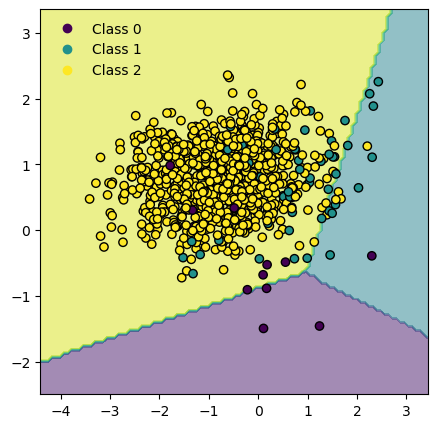

In [105]:
plt.figure(figsize=(5,5))
ax = plt.axes()
disp = DecisionBoundaryDisplay.from_estimator(clf, X, response_method="predict", alpha=0.5, ax=ax)
scatter=ax.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k")
handles, labels = scatter.legend_elements()
ax.legend(handles=handles, labels=["Class 0", "Class 1",  "Class 2"], frameon=False)

The decision function heavily favors the class with the larger number of samples, Class 2.

We see that from class 0 we have 13 examples, class 1, we have 55 examples and class 2,  we have 932 examples. This is the ratio we set using *weights* argument of *make_classification*.

Next, we will showcase a few methods for data balancing, implemented in `imblearn` library.

*Imblearn* library follows the *sklearn* approach, with the base *estimator* and adding a sampling functionality through the sample method:

- Estimator implements a *fit* method to learn from data.

- Resampler implements: *fit_resample* method.

## Under-sampling
Undersampling methods delete or select a subset of examples from the majority class. The simplest undersampling method involves randomly deleting examples from the majority class.
To perform under-sampling we can use `RandomUnderSampler`:

In [106]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(replacement=False, random_state=0)
X_resampled, y_resampled = rus.fit_resample( X, y)

The parameter *replacement=False* ensures that once a sample is selected to be part of the under-sampled majority class, it won't be selected again; thus, even though the majority class is being reduced, individual samples cannot appear multiple times in the resampled dataset.

Let's compare the number of instances in our original dataset *X*, and our subsampled dataset *X_resampled*:

In [107]:
print(X.shape)
print(X_resampled.shape)

(1000, 2)
(39, 2)


And now let's see the number of each example per class:

In [108]:
pd.Series(y_resampled).value_counts()


0    13
1    13
2    13
Name: count, dtype: int64

Notice that now all classes have the same number of examples as the minority class.
We could have set a different ratio by setting the parameter *sampling_strategy* of the `RandomUnderSampler`. The default value of this parameter is 'not minority', meaning resampling of all classes but the minority class is done.

Let's now visualize, side by side, the original dataset *X*, and our subsampled dataset *X_resampled*:

Text(0.5, 1.0, 'Dataset with under-sampling')

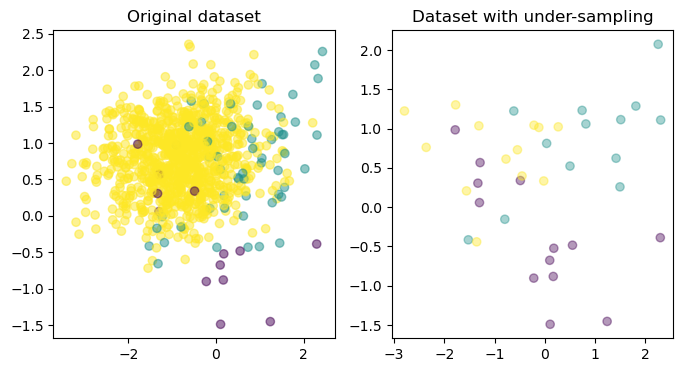

In [109]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(8, 4))
axs[0].scatter(X[:, 0], X[:, 1], alpha=0.5, c=y)
axs[0].set_title('Original dataset')

axs[1].scatter(X_resampled[:, 0], X_resampled[:, 1], alpha=0.4, c=y_resampled)
axs[1].set_title('Dataset with under-sampling')

Let's now see the decision function we learnt by fitting the sampled data to Logistic Regression. Note we will use the sampled data to learn the model, but we will plot the decision boundaries and the whole dataset.

Text(0.5, 1.0, 'Decision boundary with under-sampling')

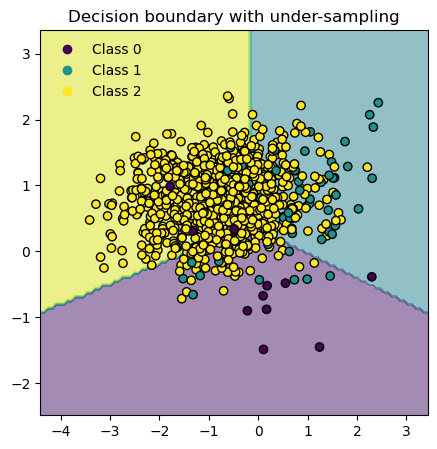

In [110]:
clf.fit(X_resampled, y_resampled)

plt.figure(figsize=(5,5))
ax = plt.axes()
disp = DecisionBoundaryDisplay.from_estimator(clf, X, response_method="predict", alpha=0.5, ax=ax)
scatter=ax.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k")
handles, labels = scatter.legend_elements()
ax.legend(handles=handles, labels=["Class 0", "Class 1",  "Class 2"], frameon=False)
ax.set_title('Decision boundary with under-sampling')

Now, the majority class does not take over the other classes during the training process, but the training of the model is done using very few data points.

## Over-sampling

Another way to deal with imbalanced data is to generate new samples of the classes which are under-represented. The most naive strategy is to generate new samples by randomly sampling with replacement the current available samples. The `RandomOverSampler` offers such scheme:

In [111]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=0)
X_resampled, y_resampled = ros.fit_resample(X, y)
print(X.shape)
print(X_resampled.shape)
pd.Series(y_resampled).value_counts()

(1000, 2)
(2796, 2)


2    932
1    932
0    932
Name: count, dtype: int64

Again, let's visualize the original and the sampled dataset:

Text(0.5, 1.0, 'Dataset with over-sampling')

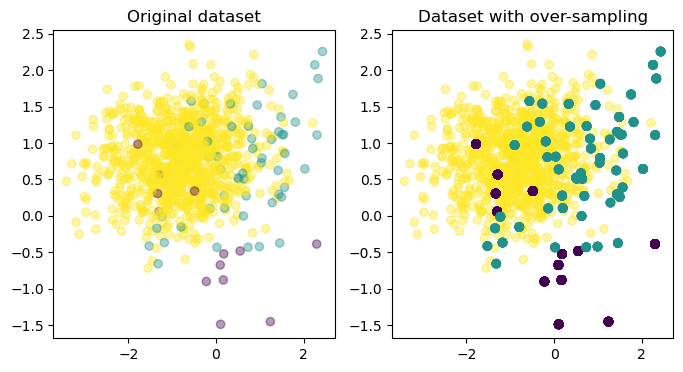

In [112]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(8, 4))
axs[0].scatter(X[:, 0], X[:, 1], alpha=0.4, c=y)
axs[0].set_title('Original dataset')

axs[1].scatter(X_resampled[:, 0], X_resampled[:, 1], alpha=0.4, c=y_resampled)
axs[1].set_title('Dataset with over-sampling')

The new samples generated are superimposing with the original samples, hence we see the same number of points on the second plot, but the color is darker, as multiple points are overlapping.

Let's now see the decision boundary:

Text(0.5, 1.0, 'Decision boundary with over-sampling')

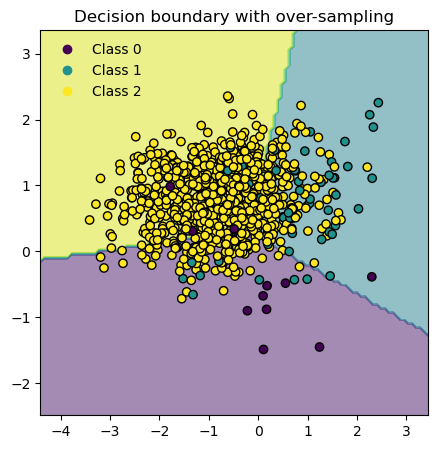

In [113]:
clf.fit(X_resampled, y_resampled)

plt.figure(figsize=(5,5))
ax = plt.axes()
disp = DecisionBoundaryDisplay.from_estimator(clf, X, response_method="predict", alpha=0.5, ax=ax)
scatter=ax.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k")
handles, labels = scatter.legend_elements()
ax.legend(handles=handles, labels=["Class 0", "Class 1",  "Class 2"], frameon=False)
ax.set_title('Decision boundary with over-sampling')

Again, the majority class does not take over the other classes during the training process. Consequently, all classes are represented by the decision function.

## SMOTE
Another popular methods to over-sample minority classes is the Synthetic Minority Oversampling Technique (SMOTE). While the `RandomOverSampler` is over-sampling by duplicating some of the original samples of the minority class, `SMOTE`  generates new samples in by interpolation.

### Numerical variables

In [114]:
from imblearn.over_sampling import SMOTE
X_resampled, y_resampled = SMOTE().fit_resample(X, y)
print(X.shape)
print(X_resampled.shape)
pd.Series(y_resampled).value_counts()

(1000, 2)
(2796, 2)


2    932
1    932
0    932
Name: count, dtype: int64

Now, let's see  our original and the sampled dataset:

Text(0.5, 1.0, 'Dataset with SMOTE')

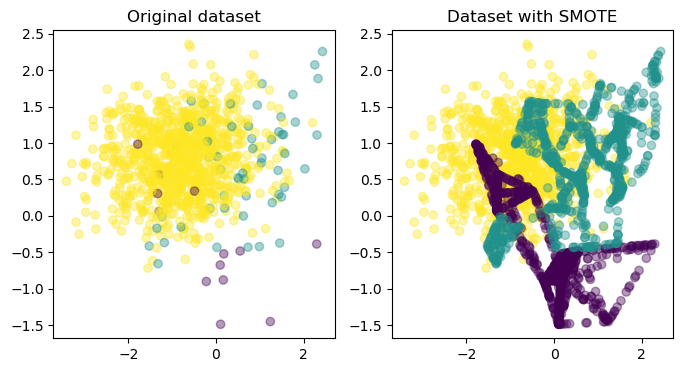

In [115]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(8, 4))
axs[0].scatter(X[:, 0], X[:, 1], alpha=0.4, c=y)
axs[0].set_title('Original dataset')

axs[1].scatter(X_resampled[:, 0], X_resampled[:, 1], alpha=0.4, c=y_resampled)
axs[1].set_title('Dataset with SMOTE')

Let's see the decision boundary found:

Text(0.5, 1.0, 'Decision boundary with SMOTE')

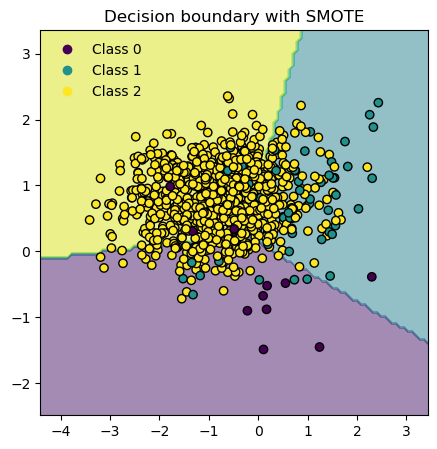

In [116]:
clf.fit(X_resampled, y_resampled)

plt.figure(figsize=(5,5))
ax = plt.axes()
disp = DecisionBoundaryDisplay.from_estimator(clf, X, response_method="predict", alpha=0.5, ax=ax)
scatter=ax.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k")
handles, labels = scatter.legend_elements()
ax.legend(handles=handles, labels=["Class 0", "Class 1",  "Class 2"], frameon=False)
ax.set_title('Decision boundary with SMOTE')

Note that SMOTE is based on finding the neighbors of data points based on distance calculations, hence doing scaling before applying SMOTE is recommended. When dealing with mixed data type such as continuous and categorical features, we need to use different versions of SMOTE.

### Categorical variables

For dealing with categorical features, extension of SMOTE, SMOTEN (SMOTE for Nominal) is used. Let's see a quick example. We will create 60 data points, with only one feature (X), with 20 of class 0 and 40 of class 1. The single feature could take values of "A", "B" or "C".


In [117]:
X = np.array(["A"] * 10 + ["B"] * 20 + ["C"] * 30, dtype=object).reshape(-1, 1)
y = np.array([0] * 20 + [1] * 40, dtype=np.int32)

Let's see the first 5 data points:

In [118]:
X[:5]

array([['A'],
       ['A'],
       ['A'],
       ['A'],
       ['A']], dtype=object)

In [119]:
pd.Series(y).value_counts()

1    40
0    20
Name: count, dtype: int64

Now, let's apply SMOTE for nominal features:

In [120]:
from imblearn.over_sampling import SMOTEN
sampler = SMOTEN(random_state=0)

X_res, y_res = sampler.fit_resample(X, y)

Let's see the new dataset:

In [121]:
pd.Series(y_res).value_counts()

0    40
1    40
Name: count, dtype: int64

Now given that SMOTE is generates synthetic examples along the line segments joining k minority class nearest neighbors, how are these neighbors calculated if we only have categorical features? This is done using a special metric where categories with similar correlation with the target vector will be considered closer. A more detailed explanation can be found [here](https://imbalanced-learn.org/stable/references/generated/imblearn.metrics.pairwise.ValueDifferenceMetric.html#imblearn.metrics.pairwise.ValueDifferenceMetric).

### Mixed data types

When dealing with mixed data type such as continuous and categorical features, SMOTENC is used. Let's create a synthetic data set with 50 datapoints, one continuous and two categorical features:

In [122]:
rng = np.random.RandomState(42)
n_samples = 50
X = np.empty((n_samples, 3), dtype=object)

# first feature can take value A, B or C
X[:, 0] = rng.choice(['A', 'B', 'C'], size=n_samples).astype(object)

# second feature is numerical
X[:, 1] = rng.randn(n_samples)

# third feature can take values 1, 2 or 3
X[:, 2] = rng.randint(3, size=n_samples)

y = np.array([0] * 20 + [1] * 30)
pd.Series(y).value_counts()

1    30
0    20
Name: count, dtype: int64

Let's see the first 5 data points:

In [123]:
X[:5]

array([['C', -0.14021849735700803, 2],
       ['A', -0.033193400066544886, 2],
       ['C', -0.7490765234433554, 1],
       ['C', -0.7783820070908942, 2],
       ['A', 0.948842857719016, 2]], dtype=object)

We need to pass the information to the SMOTENC which features are categorical, using the parameters `categorical_features`, either by passing the indices of these features or a boolean mask marking these features:

In [124]:
from imblearn.over_sampling import SMOTENC

smote_nc = SMOTENC(categorical_features=[0, 2], random_state=0)
X_resampled, y_resampled = smote_nc.fit_resample(X, y)
pd.Series(y_resampled).value_counts()

0    30
1    30
Name: count, dtype: int64

In [125]:
X_resampled[-5:]

array([['A', 0.1989993778979113, 2],
       ['B', -0.3657680728116921, 2],
       ['B', 0.8790828729585258, 2],
       ['B', 0.3710891618824609, 2],
       ['B', 0.3327240726719727, 2]], dtype=object)

The samples generated in the first and last columns are belonging to the same categories originally presented without any other extra interpolation.

To calculate the distances between the data points, in order to identify neighbors, SMOTENC computes the Euclidean distance between the feature vector using the continuous feature space. For every differing nominal feature between the considered feature vector and its potential nearest-neighbor, an additional calculation is made. More details can be found [here](https://www.cs.cmu.edu/afs/cs/project/jair/pub/volume16/chawla02a-html/node15.html).

 Oversampling and undersampling can also be extended to regression problems when relevant values of the target are underrepresented. A case in point would be the prediction of salaries, in which mid-range salaries are likely to be prevalent, yet instances of higher incomes would be much more rare, culminating in the model performing less optimally in this bracket. 

Imbalanced regression is a less commonly discussed topic than imbalanced classification, but unevenly distributed targets can often occur, and specific approaches can be considered for these situations: aside from other methods like altering the target's distribution to be closer to the Gaussian's or adopting scoring functions that focus on rare instances, an example pertaining to sampling is SMOGN that removes samples of the majority class and creates new samples of the minority class through interpolation (with the addition of noise). More details can be found [here](https://github.com/nickkunz/smogn).

## Avoiding data leakage with pipeline

Special attention must be paid when data set balancing is done. Data balancing is only performed on the training dataset in order for the algorithm to learns a model. 
**Balancing is not performed on the holdout test or test dataset**. 
Doing the balancing on the entire dataset before splitting it into a train and a test partitions leads to two problematic issues:
- The resampling procedure might use information about test samples to either generate or select some of the samples for training. 
- The model will not be tested on a dataset with class distribution similar and representative to the real use-case:  misleading and perhaps overly optimistic estimation of performance.


While it is a pretty straightforward conclusion that the dataset balancing should be done only after the train test split, balancing the training set is problematic if we decide to do cross-validation. Why is that? Recall that in cross-validation, folds of the training dataset will be used for training and also for validation.  `imblearn.Pipeline` object allows us to apply dataset balancing only to the training folds.

Let's now import an unbalanced dataset using `sklearn`'s `fetch_openml`, which can fetch a dataset from https://www.openml.org/ by name or dataset id.

In [126]:
from sklearn.datasets import fetch_openml
data = fetch_openml('mammography', as_frame=True, parser='auto')
X, y = data.data, data.target
X.shape

(11183, 6)

Let's check the class distribution:

In [127]:
y.value_counts()

class
-1    10923
1       260
Name: count, dtype: int64

Let's change y to have classes 0 and 1 (instead of -1 and 1) to allow *sklearn* to determine the positive class more easily. We will use `.cat.rename_categories` pandas function for renaming categories:

In [128]:
y = y.cat.rename_categories({'-1': 0, '1': 1})
y.value_counts()

class
0    10923
1      260
Name: count, dtype: int64

In [129]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=0)

Note that we used the parameter `stratify=y` to ensures that the train/test split preserves the same proportion of each class in y as in the original dataset.  Without it, we might get an uneven split, which can lead to biased model training and unreliable evaluation  with imbalanced datasets.

As in *scikit-learn*, in *imbalanced-learn*, we will be using a *Pipeline* to avoid data leakage. **A traditional *scklearn* Pipeline cannot be used with sampling methods.**

In [130]:
from imblearn.pipeline import Pipeline 

undersample_pipe = Pipeline([('sampling', RandomUnderSampler()), 
                             ('classifier', LogisticRegression(solver='liblinear'))])

Note that the pipeline, when used in cross validation, first splits into training and validation folds, and then applies sampling subsequently only to the training ones. When called `predict` on a `imblearn.Pipeline` object, it will skip the sampling method and leave the data as it is to be passed to next transformer. Hence,  we train the dataset on the sampled data, but evaluate on non-sampled data. You can also consult the following [link](https://kiwidamien.github.io/how-to-do-cross-validation-when-upsampling-data.html) for more details.

Now, let's put together sampling and model tuning. Recall that we can use *get_params()* to see the names of all the parameters of an estimator.

In [131]:
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import MinMaxScaler, StandardScaler

pipe = Pipeline([
    ('scaling', StandardScaler()), 
    ('sampling', SMOTE()), 
    ('classifier', LogisticRegression(solver='liblinear'))])

pipe.get_params()

{'memory': None,
 'steps': [('scaling', StandardScaler()),
  ('sampling', SMOTE()),
  ('classifier', LogisticRegression(solver='liblinear'))],
 'transform_input': None,
 'verbose': False,
 'scaling': StandardScaler(),
 'sampling': SMOTE(),
 'classifier': LogisticRegression(solver='liblinear'),
 'scaling__copy': True,
 'scaling__with_mean': True,
 'scaling__with_std': True,
 'sampling__k_neighbors': 5,
 'sampling__random_state': None,
 'sampling__sampling_strategy': 'auto',
 'classifier__C': 1.0,
 'classifier__class_weight': None,
 'classifier__dual': False,
 'classifier__fit_intercept': True,
 'classifier__intercept_scaling': 1,
 'classifier__l1_ratio': 0.0,
 'classifier__max_iter': 100,
 'classifier__n_jobs': None,
 'classifier__penalty': 'deprecated',
 'classifier__random_state': None,
 'classifier__solver': 'liblinear',
 'classifier__tol': 0.0001,
 'classifier__verbose': 0,
 'classifier__warm_start': False}

In [132]:
param_grid = {'classifier__penalty': ["l1","l2"],
        'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100]
        }
grid = GridSearchCV(pipe, param_grid, cv=10, scoring = 'recall', n_jobs=-1)
grid.fit(X_train, y_train)
print('Best cross-validation score: ', grid.best_score_)
print('Best params:' , grid.best_params_)

Best cross-validation score:  0.8726315789473684
Best params: {'classifier__C': 0.001, 'classifier__penalty': 'l2'}


C:\ProgramData\anaconda3\envs\ml2026\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


We could also use the `Pipeline` to test which sampling method gives the best performance (according to the scoring method we choose):

In [133]:
pipe = Pipeline([
    ('scaling', StandardScaler()), 
    ('sampling', RandomOverSampler()),
    ('classifier', LogisticRegression(solver='liblinear'))])

param_grid = [
    {'classifier': [LogisticRegression(solver='liblinear')], 
     'sampling': [None, RandomUnderSampler(), RandomOverSampler(), SMOTE()],
     'classifier__penalty': ["l1","l2"], 
     'classifier__C':  [0.001, 0.01, 0.1, 1, 10, 100]}]

grid = GridSearchCV(pipe, param_grid, cv=10, scoring = 'recall', n_jobs=-1)
grid.fit(X_train, y_train)

print('Best cross-validation score: ', grid.best_score_)
print('Best params:' , grid.best_params_)

Best cross-validation score:  0.9186842105263159
Best params: {'classifier': LogisticRegression(solver='liblinear'), 'classifier__C': 0.001, 'classifier__penalty': 'l2', 'sampling': RandomUnderSampler()}


C:\ProgramData\anaconda3\envs\ml2026\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


## Key points

To scale the data:
- min max normalization, use `MinMaxScaler`
- for standardization, use `StandardScaler`

To encode categorical variables:
- one hot encoding use `OneHotEncoder`
- ordinal encoding use `OrdinalEncoder`
- target encoding use `TargetEncoder`

To impute missing values use `SimpleImputer`

To perform hyperparameter tuning with cross validation:
- to check all possible listed parameter combinations use `GridSearchCV`
- to check a given number of parameter settings is sampled from the specified distributions use `RandomizedSearchCV`, checked number of combinations is specified with `n_iter`
- always use the appropriate scoring strategy to evaluate the performance of the cross-validated model on the holdout fold: `scoring` parameter


To apply different transformation to different columns use  `ColumnTransformer`
- columns of the transformed data frame might be in different order, depends on the order of trasnformations and columns listed
- by default, only the specified columns in transformers are transformed and combined in the output, and the non-specified columns are dropped. Use parameter `remainder='passthrough'`, to leave all remaining columns that were not specified in transformers, present in the output
- to access individual tranformation within the transformer, use the attribute `named_transformers_`

To chain pre-processing steps together with modeling use `Pipeline`:
- use as input for Grid and Randomizd search as it avoids data leakage
- One of the steps in the `Pipeline` can also be `ColumnTransformer`, and `Pipeline` can also be a step in `ColumnTransformer`:  ColumnTransformer applies the assigned transformations simultaneously, the Pipeline executes its steps sequentially.


For imbalanced data make sure to:
- use `stratify=y` to make sure that train test split preserves the same proportion of each class in y as in the original dataset
- use `imblearn` pipeline and one of the imblearn balancing approaches:
  - `RandomOverSampler`
  - `RandomUnderSampler`
  - `SMOTE` for all numerical features, `SMOTEN` for all nominal, `SMOTENC` for mixed type features
- you can also adjust weighing of classes for some models, which we will cover in the next notebook

**Make sure you know how to**:
- set up an example pipeline with various preprocessing steps 
- use pipeline to search over different models and their parameters